In [9]:
import numpy as np
from LiouvilleSpectroscopyV6 import LiouvilleSpectroscopySolver,SpectroscopyPlotter


## Model Parameter

In [10]:
MODEL_PARAMS = {
    # -------------------------------------------------------------------------
    # Orbital sector
    # -------------------------------------------------------------------------
    # Energy of the dark orbital state relative to the ground state.
    # Unit: same energy unit as all other energies in the model
    # (eV if the rest of the model is expressed in eV).
    "Delta_dark": 0.9,

    # Energy of the bright orbital state.
    #
    # Warning: the SOC notebook sometimes used the key "Delta_Bright".
    # The build_soc_hamiltonian function reads exactly "Delta_bright".
    "Delta_bright": 1.5,

    # Effective spin-orbit coupling strength.
    "Lambda_SOC": 0.15,

    # Number of levels kept in the bosonic/spin-Peierls sector.
    # The total Hilbert dimension is:
    #     3 orbital states x n_bosons.
    "n_bosons": 2,

    # -------------------------------------------------------------------------
    # Spin-Peierls dispersion parameters
    # -------------------------------------------------------------------------
    # Physical temperature used to calculate the spin-Peierls gap.
    # This same value is also used by the solver to construct the thermal 
    # rho when no initial density matrix is provided.
    "T": 7.0,

    # Zero-field spin-Peierls transition temperature.
    "T_SP_0": 14.0,

    # External magnetic field.
    "B": 0.0,

    # Exchange scale of the spin sector.
    "J": 1.0,

    # Dimerization amplitude at zero temperature.
    "delta_0": 0.01,

    # Critical exponent used for the temperature dependence of the
    # dimerization.
    "beta": 0.5,

    # -------------------------------------------------------------------------
    # Effective coupling associated with dimerization
    # -------------------------------------------------------------------------
    # Normalized internal distance of the dimer.
    "a_dimer": 1.0,

    # Dimerization amplitude used in the coupling term.
    "delta_dimerisation": 0.01,

    # Small mixing factor/symmetry breaking.
    #
    # Warning: the SOC notebook sometimes used "alpha_dimeraisation".
    # The key read here is "alpha_dimerisation".
    "alpha_dimerisation": 0.01,

    # Coupling symmetry:
    #   "odd"   -> sin(k a/2)
    #   "even"  -> cos(k a/2)
    #   "mixed" -> sin(k a/2) + eta cos(k a/2)
    "parity": "odd",
}

## Dissipative parameter

In [11]:
DISSIPATION_PARAMS = {
    # Taux de relaxation dans le secteur bosonique/spin.
    "gamma_spin": 0.1,

    # Taux de relaxation des états orbitaux sombre et brillant vers le
    # fondamental.
    "gamma_orb": 0.1,
}

## Solver numerical parameter

In [12]:
SOLVER_PARAMS = {
    # -------------------------------------------------------------------------
    # Spectral resolution and thermal state
    # -------------------------------------------------------------------------
    # Imaginary broadening of the resolvent:
    #     G(w) = [(w + i Eta) I - L]^{-1}.
    # A larger value broadens and smoothes out the peaks.
    "Eta": 0.1,

    # Temperature used for the default thermal state.
    #
    # If initial_density_matrix is provided to feed_model(), this temperature
    # is no longer used to define rho(0), but it may still be useful for the 
    # physical model since MODEL_PARAMS["T"] also controls the dispersion.
    "T": MODEL_PARAMS["T"],

    # Chemical potential used only when constructing the default thermal state.
    "mu": 0.0,

    # Tolerance used to separate J_plus and J_minus in the rotating wave 
    # approximation.
    "rwa_tol": 1e-6,

    # Tolerance for rho validations: hermiticity, trace, and positivity.
    "density_matrix_tolerance": 1e-10,

    # -------------------------------------------------------------------------
    # Liouville backend choice
    # -------------------------------------------------------------------------
    # "auto"   : dense for small Liouville spaces, sparse otherwise.
    # "dense"  : forces dense arrays.
    # "sparse" : forces sparse matrices.
    "backend": "auto",

    # In "auto" mode, the dense backend is used if dim(H)^2 is less than
    # or equal to this value.
    "dense_liouville_cutoff": 512,

    # -------------------------------------------------------------------------
    # Sparse resolution
    # -------------------------------------------------------------------------
    # "auto"   : tries a direct factorization, then GMRES if necessary.
    # "direct" : enforces direct factorization.
    # "gmres"  : uses the iterative GMRES solver.
    "sparse_solver": "auto",

    # Tolerances and maximum number of iterations for GMRES.
    "sparse_gmres_rtol": 1e-8,
    "sparse_gmres_atol": 0.0,
    "sparse_gmres_maxiter": None,

    # If True, constructs and keeps exp(-i L tau2) in sparse format.
    # This speeds up repeated calls to the same tau2 at the cost of memory.
    "cache_sparse_tau2": False,

    # -------------------------------------------------------------------------
    # Resolvent cache
    # -------------------------------------------------------------------------
    # Keep factorizations/resolvents associated with frequencies.
    "cache_resolvents": True,

    # None keeps all frequencies from the current scan. An integer imposes
    # a maximum size on the cache.
    "max_resolvent_cache": None,

    # -------------------------------------------------------------------------
    # Grid parallelization (omega1, omega3)
    # -------------------------------------------------------------------------
    # Main options:
    #   "serial"        : no parallelism;
    #   "threading"     : joblib threads;
    #   "loky"          : joblib processes;
    #   "multiprocessing";
    #   "process"       : ProcessPoolExecutor.
    #
    # For a small dense model, "threading" or even "serial" can be more
    # efficient than processes, which impose a serialization cost.
    "parallel_backend": "threading",

    # Joblib convention:
    #   1  -> sequential;
    #   -1 -> all available cores;
    #   -2 -> all cores except one.
    "n_jobs": 6,

    # Number of omega3 columns grouped into a single parallel task.
    # None lets the solver choose automatically.
    "parallel_block_size": None,

    # Optional limit on the number of internal BLAS/OpenMP threads during 
    # external parallelism. Setting to 1 can avoid CPU oversubscription.
    "blas_threads": 1,

    # -------------------------------------------------------------------------
    # Components calculated by generate_2D_spectra
    # -------------------------------------------------------------------------
    # "both"        : rephasing + unrephasing + absorptive;
    # "rephasing"   : rephasing only;
    # "unrephasing" : unrephasing only.
    "spectrum_components": "both",
}


# Practical dictionary passed to functions that read parameters from
# multiple categories. Keys in SOLVER_PARAMS overwrite identical physical 
# keys; here T is intentionally identical in both dictionaries.
ALL_PARAMS = {
    **MODEL_PARAMS,
    **DISSIPATION_PARAMS,
    **SOLVER_PARAMS,
}

## Scan parameter


In [13]:
SCAN_PARAMS = {
    # Nombre de points de la zone de Brillouin.
    "total_kpoints": 100,

    # Bornes de k. Le solver intègre ensuite la réponse avec dk/(2 pi).
    "k_min": -np.pi,
    "k_max": np.pi,

    # Grille commune utilisée pour omega1 et omega3.
    "omega_min": -2.5,
    "omega_max": 2.5,
    "omega_points": 150,

    # Temps d'attente entre les deuxième et troisième interactions.
    "tau2": 5.0,
}

## Exemple control

In [14]:
EXAMPLE_OPTIONS = {
    # "dipole" uses mu_opt and interaction_type="dipole".
    # "current" uses J_raw and interaction_type="current".
    "interaction_mode": "dipole",

    # If False, the solver constructs the default thermal state using T and mu.
    # If True, the example explicitly provides rho0_site.
    "use_custom_density_matrix": False,

    # If True, UFSS generates standard rephasing and unrephasing groups.
    # If False, V6 retains its six standard default pathways.
    "generate_pathways_with_ufss": True,

    # Calculating the six individual matrices adds workload to the main 
    # calculation. Disable if only total spectra are needed.
    "calculate_individual_pathways": True,

    # Display plots.
    "show_plots": True,
}


## Model functions

In [15]:
def spin_peierls_dispersion(k, temperature, magnetic_field, exchange,
                            transition_temperature, delta_zero, beta):
    """
    Calculate the spin-Peierls dispersion epsilon(k) and the gap Delta.

    Parameters
    ----------
    k : float
        Wave vector.
    temperature : float
        Physical temperature T.
    magnetic_field : float
        Magnetic field B.
    exchange : float
        Exchange scale J.
    transition_temperature : float
        Transition temperature T_SP at zero field.
    delta_zero : float
        Dimerization at zero temperature.
    beta : float
        Critical exponent of the dimerization.
    """
    field_coefficient = 0.004
    t_sp = transition_temperature * (
        1.0 - field_coefficient * magnetic_field**2
    )
    t_sp = max(0.0, t_sp)

    if t_sp > 0.0 and temperature < t_sp:
        delta = delta_zero * (1.0 - temperature / t_sp) ** beta
    else:
        delta = 0.0

    # Cross-Fisher relation: Delta proportional to J * delta^(2/3).
    gap = 2.0 * exchange * delta ** (2.0 / 3.0) if delta > 0 else 0.0
    velocity = np.pi * exchange / 2.0
    epsilon_k = np.sqrt(gap**2 + (velocity * np.sin(k)) ** 2)
    return epsilon_k, gap


def effective_soc_coupling(
    k,
    delta_dimerisation,
    alpha_dimerisation,
    a_dimer=1.0,
    parity="odd",
):
    """
    Calculate the SOC coupling form factor in the dimerized lattice.
    """
    eta = delta_dimerisation * alpha_dimerisation
    phase = k * a_dimer / 2.0

    if parity == "odd":
        return np.sin(phase)
    if parity == "even":
        return np.cos(phase)
    if parity == "mixed":
        return np.sin(phase) + eta * np.cos(phase)
    raise ValueError("parity must be 'odd', 'even', or 'mixed'.")


def build_soc_hamiltonian(k_array, params):
    """
    Build H(k), J(k), and mu(k) for the notebook's SOC model.

    Basis
    -----
    The product basis is organized as:

        |orbital> tensor |bosonic level>

    with three orbital states:

        0 : ground state
        1 : dark state
        2 : bright state

    Returns
    -------
    H_raw : ndarray, shape (N_k, d, d)
        Hamiltonian in the site/product basis.
    J_raw : ndarray, shape (N_k, d, d)
        Current operator dH/dk.
    mu_opt_array : ndarray, shape (N_k, d, d)
        Dipole operator connecting the ground state and the bright state.
    """
    n_k = len(k_array)
    n_bosons = int(params.get("n_bosons", 2))
    dim = 3 * n_bosons

    lambda_soc = params.get("Lambda_SOC", 0.1)
    delta_dark = params.get("Delta_dark", 0.9)
    delta_bright = params.get("Delta_bright", 1.5)

    temperature = params.get("T", 5.0)
    magnetic_field = params.get("B", 0.0)
    exchange = params.get("J", 1.0)
    transition_temperature = params.get("T_SP_0", 14.0)
    delta_zero = params.get("delta_0", 0.1)
    beta = params.get("beta", 0.5)

    a_dimer = params.get("a_dimer", 1.0)
    delta_dimerisation = params.get("delta_dimerisation", 0.01)
    alpha_dimerisation = params.get("alpha_dimerisation", 0.01)
    parity = params.get("parity", "odd")

    H_raw = np.zeros((n_k, dim, dim), dtype=complex)
    J_raw = np.zeros((n_k, dim, dim), dtype=complex)
    mu_opt_array = np.zeros((n_k, dim, dim), dtype=complex)

    # Local orbital Hamiltonian.
    H_orbital = np.zeros((3, 3), dtype=complex)
    H_orbital[1, 1] = delta_dark
    H_orbital[2, 2] = delta_bright

    # Dark-bright mixing induced by SOC.
    L_operator = np.zeros((3, 3), dtype=complex)
    L_operator[1, 2] = 1.0
    L_operator[2, 1] = 1.0

    # Ground state <-> bright state optical dipole.
    mu_orbital = np.zeros((3, 3), dtype=complex)
    mu_orbital[0, 2] = 1.0
    mu_orbital[2, 0] = 1.0

    # Truncated annihilation operator for the bosonic sector.
    annihilation = np.zeros((n_bosons, n_bosons), dtype=complex)
    for level in range(1, n_bosons):
        annihilation[level - 1, level] = np.sqrt(level)

    creation = annihilation.conj().T
    number_operator = creation @ annihilation
    displacement_operator = annihilation + creation

    identity_orbital = np.eye(3, dtype=complex)
    identity_spin = np.eye(n_bosons, dtype=complex)

    H_local = np.kron(H_orbital, identity_spin)
    mu_optical = np.kron(mu_orbital, identity_spin)

    velocity = np.pi * exchange / 2.0
    phase_derivative = a_dimer / 2.0
    eta_dimer = delta_dimerisation * alpha_dimerisation

    for i_k, k in enumerate(k_array):
        epsilon_k, _ = spin_peierls_dispersion(
            k,
            temperature,
            magnetic_field,
            exchange,
            transition_temperature,
            delta_zero,
            beta,
        )

        if epsilon_k != 0:
            d_epsilon_dk = (
                velocity**2 * np.sin(k) * np.cos(k) / epsilon_k
            )
        else:
            d_epsilon_dk = 0.0

        H_spin = np.kron(
            identity_orbital,
            epsilon_k * number_operator,
        )
        J_spin = np.kron(
            identity_orbital,
            d_epsilon_dk * number_operator,
        )

        coupling = effective_soc_coupling(
            k,
            delta_dimerisation,
            alpha_dimerisation,
            a_dimer,
            parity,
        )

        phase = k * a_dimer / 2.0
        if parity == "odd":
            d_coupling_dk = phase_derivative * np.cos(phase)
        elif parity == "even":
            d_coupling_dk = -phase_derivative * np.sin(phase)
        elif parity == "mixed":
            d_coupling_dk = (
                phase_derivative * np.cos(phase)
                - eta_dimer * phase_derivative * np.sin(phase)
            )
        else:
            raise ValueError("parity must be 'odd', 'even', or 'mixed'.")

        H_soc = (
            lambda_soc
            * coupling
            * np.kron(L_operator, displacement_operator)
        )
        J_soc = (
            lambda_soc
            * d_coupling_dk
            * np.kron(L_operator, displacement_operator)
        )

        H_raw[i_k] = H_local + H_spin + H_soc
        J_raw[i_k] = J_spin + J_soc
        mu_opt_array[i_k] = mu_optical

    return H_raw, J_raw, mu_opt_array

def build_minimal_lindblad_operators(params):
    """
    Build the three relaxation channels for the SOC notebook.

    Returns
    -------
    list of tuple
        Each entry is ``(C, gamma)``:

        - ``C`` is an operator in the site/product basis;
        - ``gamma`` is the Lindblad rate applied by the solver.

    Notes
    -----
    The returned operators do not contain ``sqrt(gamma)``. The solver
    receives gamma separately and constructs the dissipator itself.
    """
    n_bosons = int(params.get("n_bosons", 2))
    gamma_spin = params.get("gamma_spin", 0.05)
    gamma_orbital = params.get("gamma_orb", 0.1)

    identity_orbital = np.eye(3, dtype=complex)
    identity_spin = np.eye(n_bosons, dtype=complex)

    annihilation = np.zeros((n_bosons, n_bosons), dtype=complex)
    for level in range(1, n_bosons):
        annihilation[level - 1, level] = np.sqrt(level)

    collapse_operators = []

    # Relaxation of the bosonic sector.
    C_spin = np.kron(identity_orbital, annihilation)
    collapse_operators.append((C_spin, gamma_spin))

    # Relaxation from bright state -> ground state.
    bright_to_ground = np.zeros((3, 3), dtype=complex)
    bright_to_ground[0, 2] = 1.0
    C_bright_ground = np.kron(bright_to_ground, identity_spin)
    collapse_operators.append((C_bright_ground, gamma_orbital))

    # Relaxation from dark state -> ground state.
    dark_to_ground = np.zeros((3, 3), dtype=complex)
    dark_to_ground[0, 1] = 1.0
    C_dark_ground = np.kron(dark_to_ground, identity_spin)
    collapse_operators.append((C_dark_ground, gamma_orbital))

    return collapse_operators


def build_custom_initial_density_matrix(params):
    """
    Example of rho(0) provided in the site/product basis.

    Here, the entire population is placed in:

        |ground orbital> tensor |bosonic level 0>.

    To define a statistical mixture, place multiple populations along the
    diagonal. ``set_initial_density_matrix`` normalizes the trace by default.
    Coherences can be added off-diagonal as long as the matrix remains
    Hermitian and positive semi-definite.
    """
    dimension = 3 * int(params.get("n_bosons", 2))
    rho0_site = np.zeros((dimension, dimension), dtype=complex)
    rho0_site[0, 0] = 1.0
    return rho0_site

--- Model loading (interaction type: dipole) ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Dissipation operators updated.
{'name': 'R1', 'component': 'rephasing', 'interactions': ('Bu', 'Ku', 'Bd'), 'pulse_indices': (0, 1, 2), 'amplitude': (1+0j), 'bra_sign': 1, 'coefficient': (1+0j)}
{'name': 'R2', 'component': 'rephasing', 'interactions': ('Bu', 'Bd', 'Ku'), 'pulse_indices': (0, 1, 2), 'amplitude': (1+0j), 'bra_sign': 1, 'coefficient': (1+0j)}
{'name': 'R3', 'component': 'rephasing', 'interactions': ('Bu', 'Ku', 'Ku'), 'pulse_indices': (0, 1, 2), 'amplitude': (1+0j), 'bra_sign': -1, 'coefficient': (-1+0j)}
{'name': 'R4', 'component': 'unrephasing', 'interactions': ('Ku', 'Bu', 'Ku'), 'pulse_indices': (0, 1, 2), 'amplitude': (1+0j), 'bra_sign': -1, 'coefficient': (-1+0j)}
{'name': 'R5', 'component': 'unrephasing', 'interactions': ('Ku', 'Bu', 'Bd'), 'pulse_indices': (0, 1, 2), 'amplitude': (1+0j), 'bra_sign': 1, 'coefficient': (1+0j)}
{'name': 'R6', 'compone

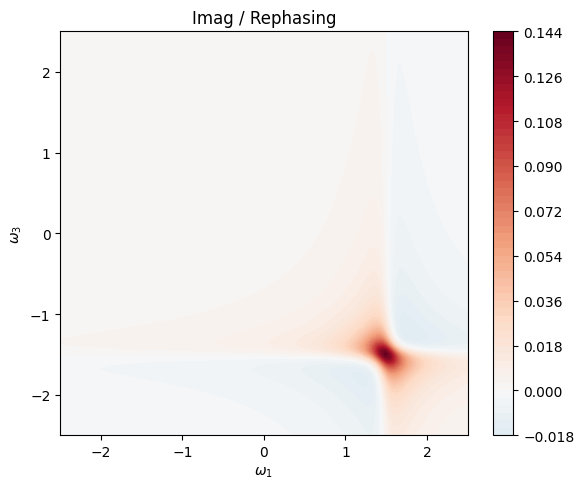

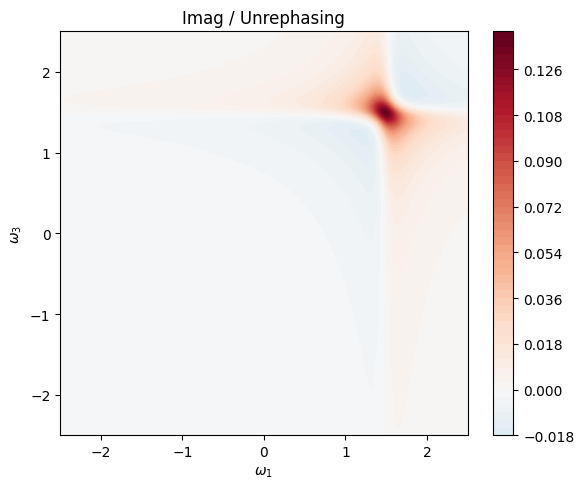

population time: 64 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


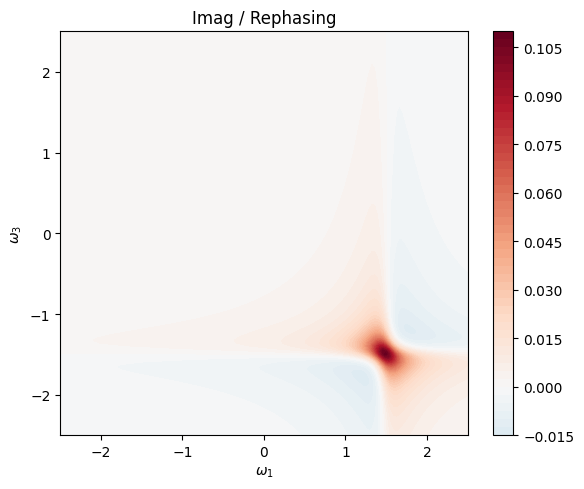

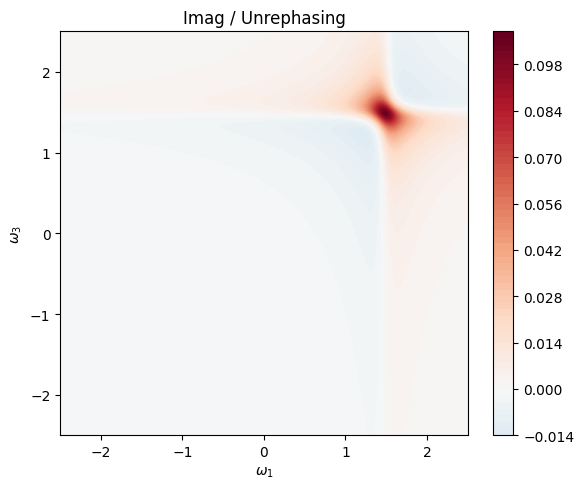

population time: 66 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


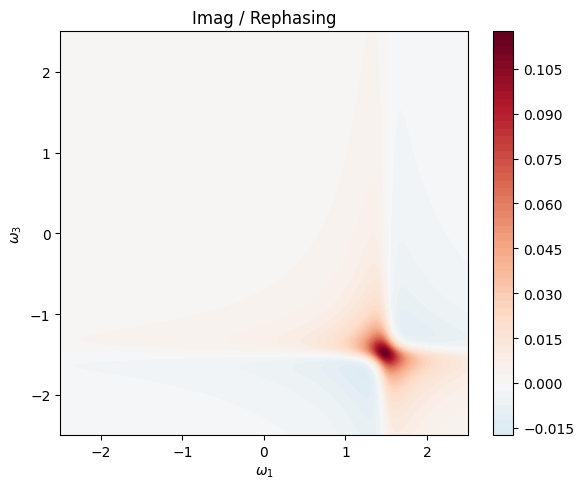

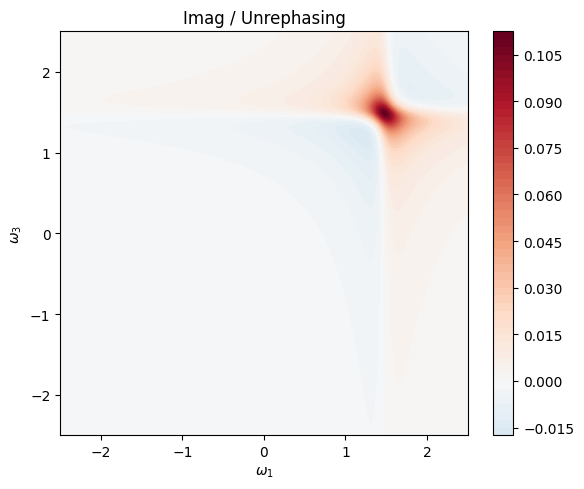

population time: 68 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


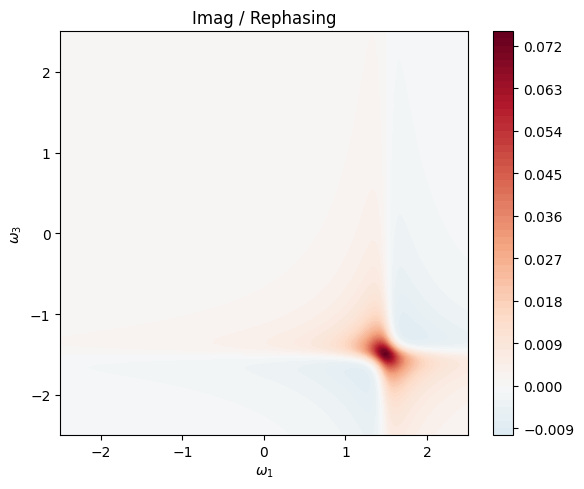

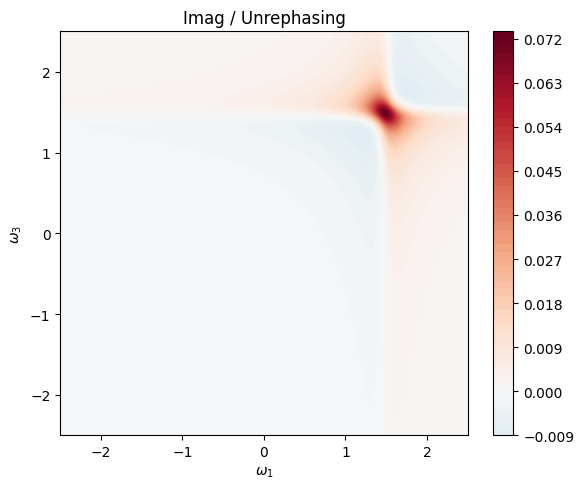

population time: 70 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


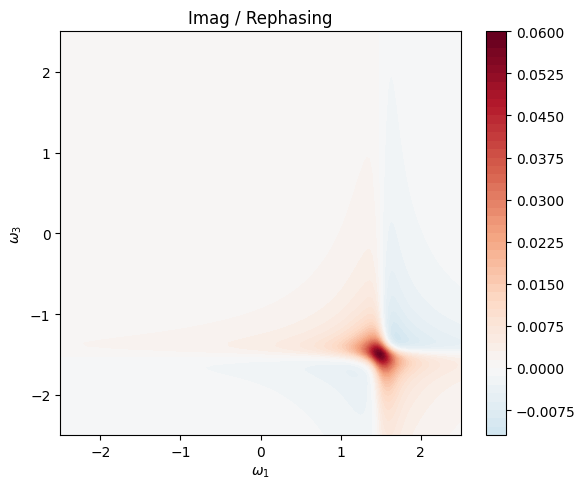

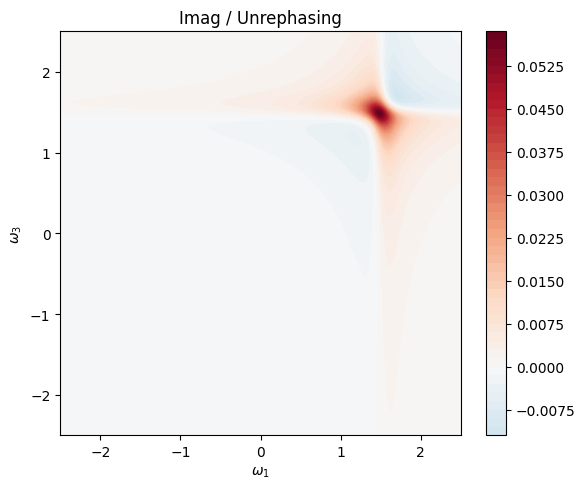

population time: 72 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


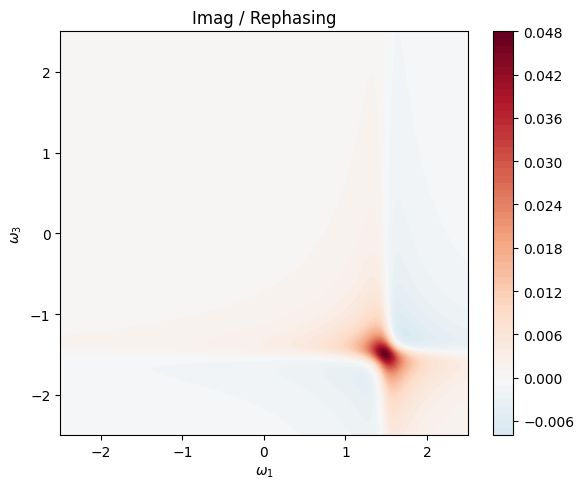

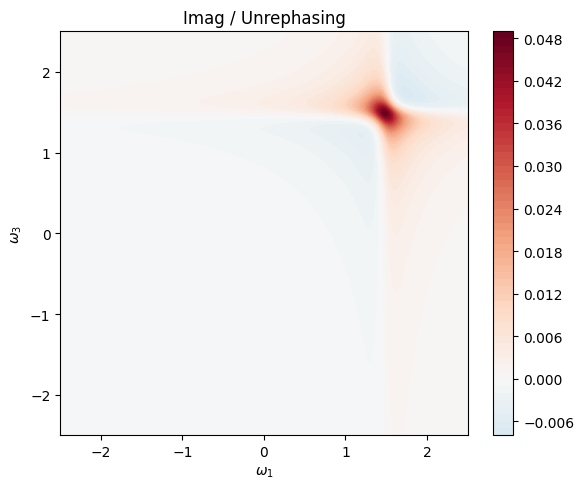

population time: 74 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


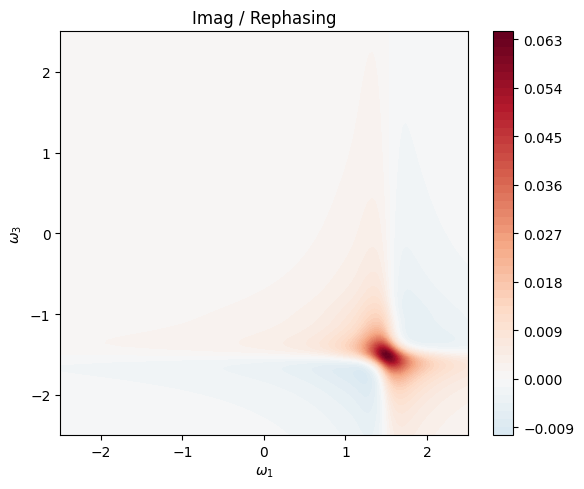

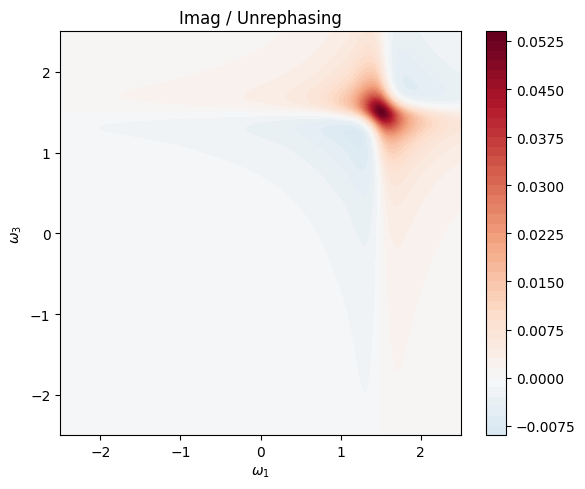

population time: 76 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


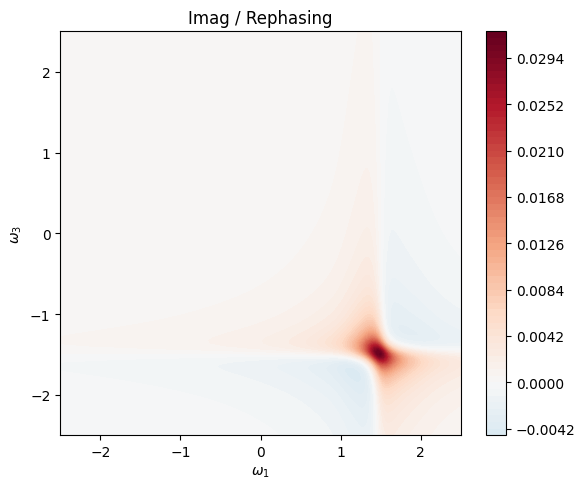

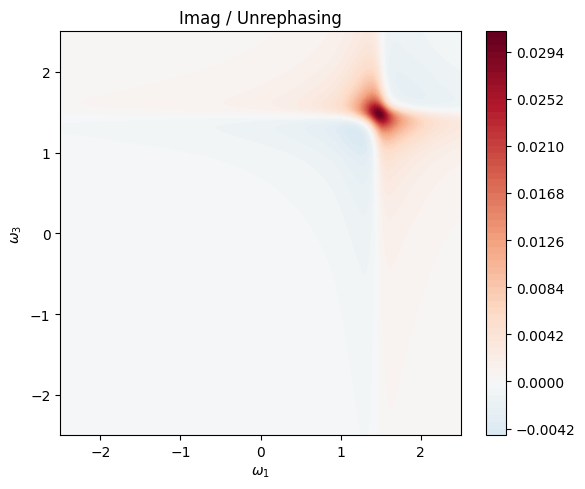

population time: 78 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


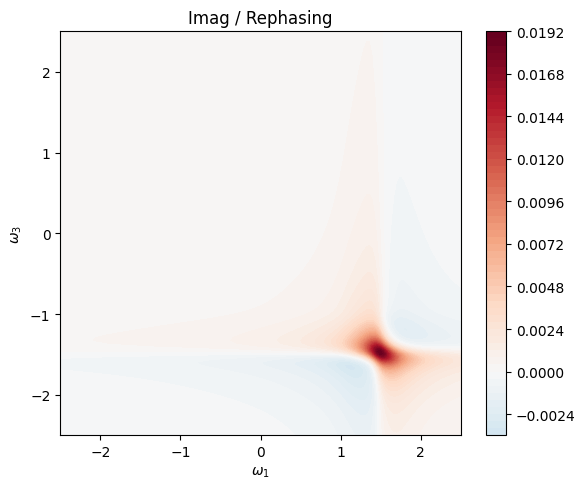

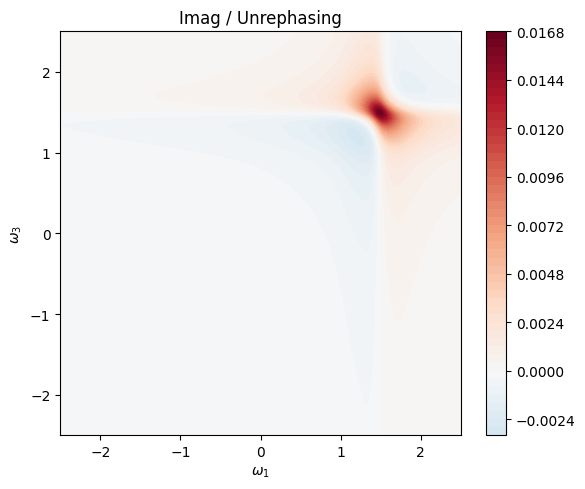

population time: 80 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


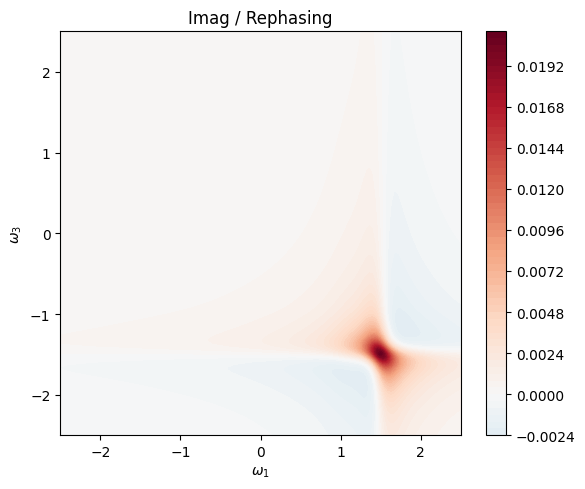

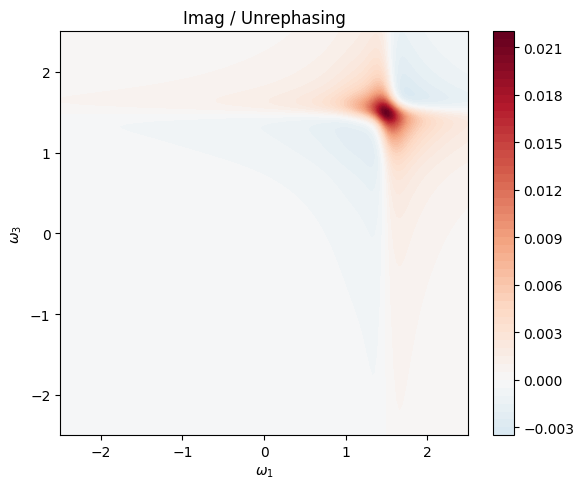

population time: 82 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


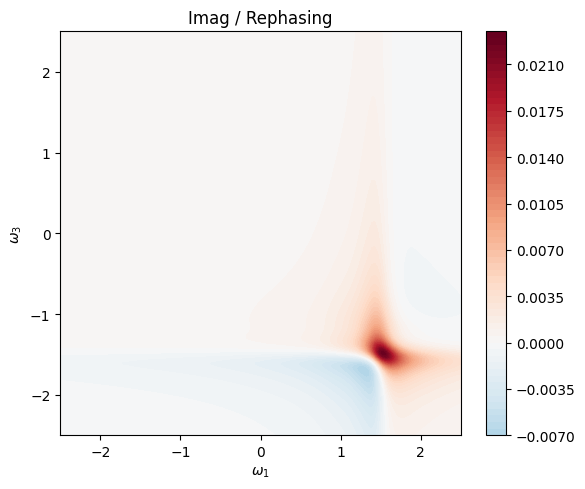

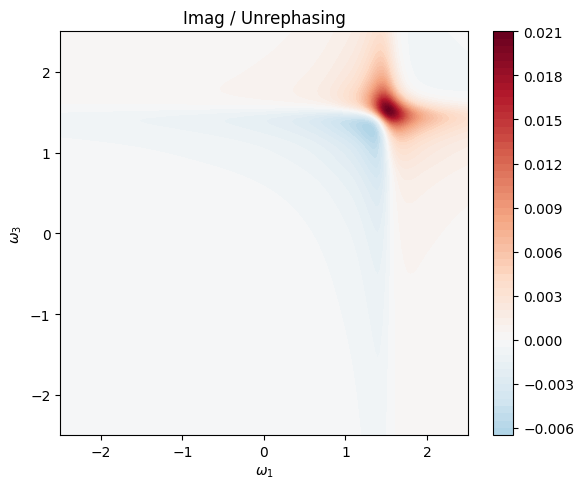

population time: 84 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


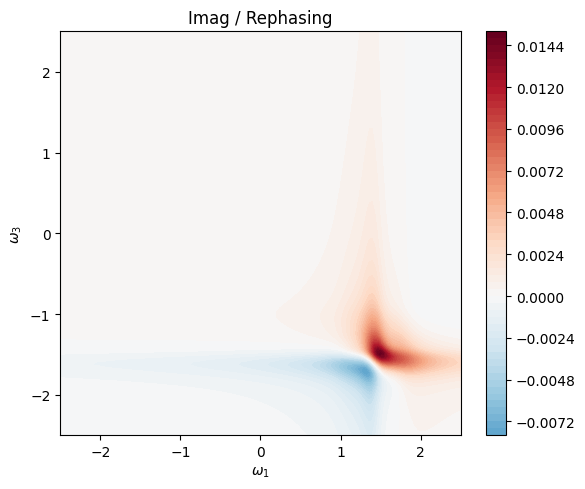

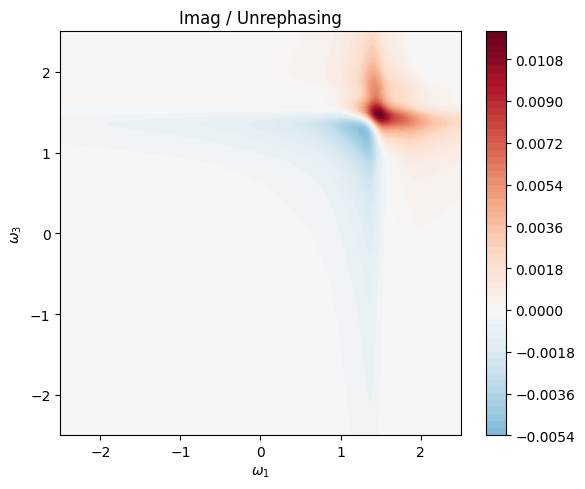

population time: 86 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


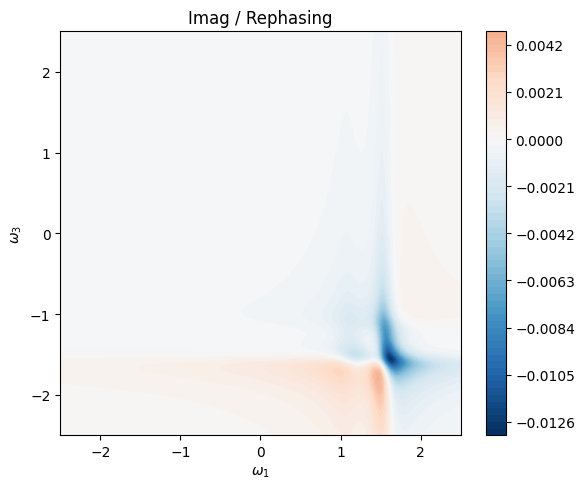

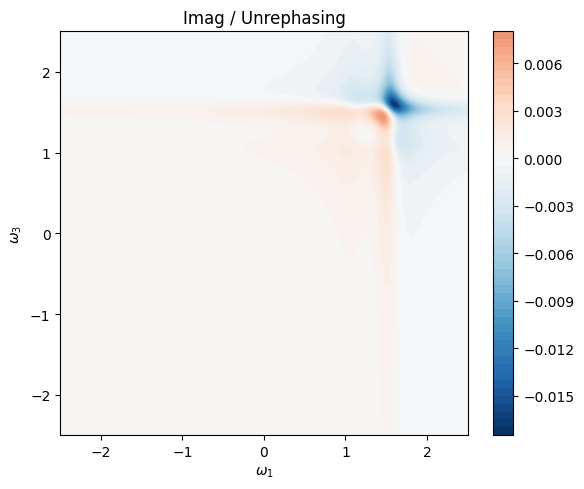

population time: 88 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


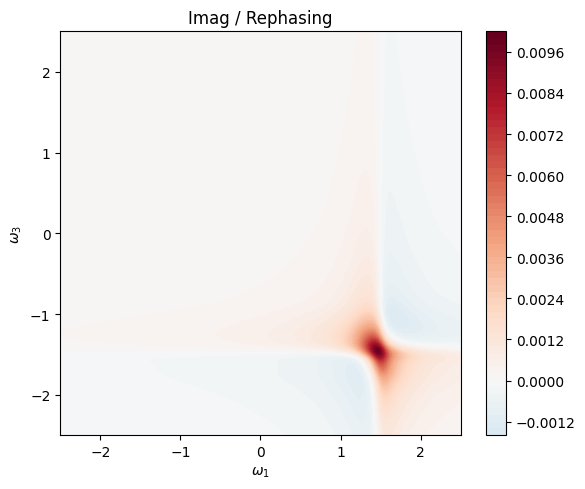

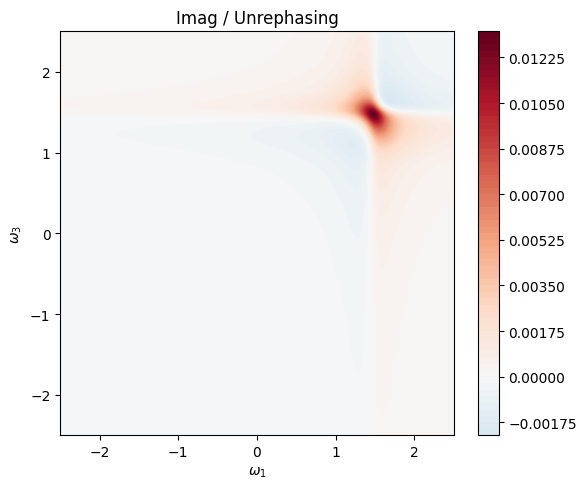

population time: 90 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


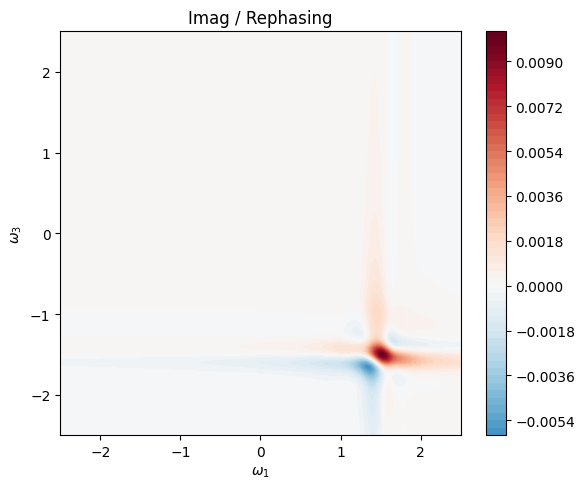

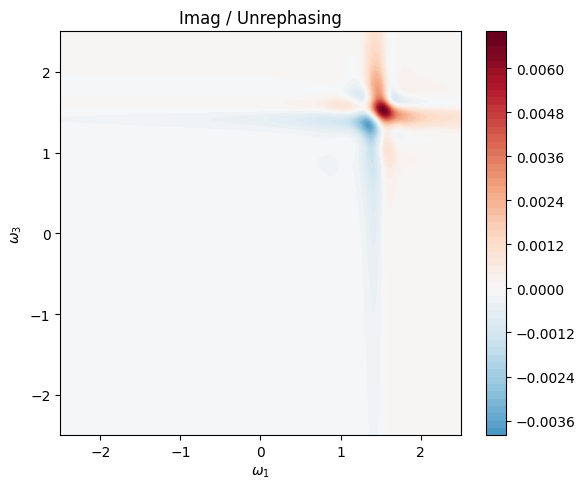

population time: 92 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


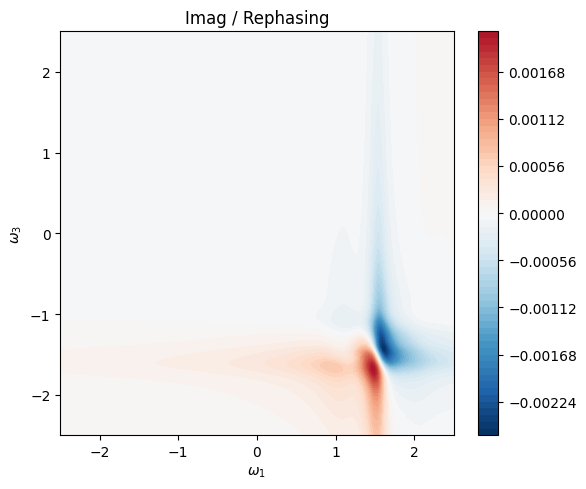

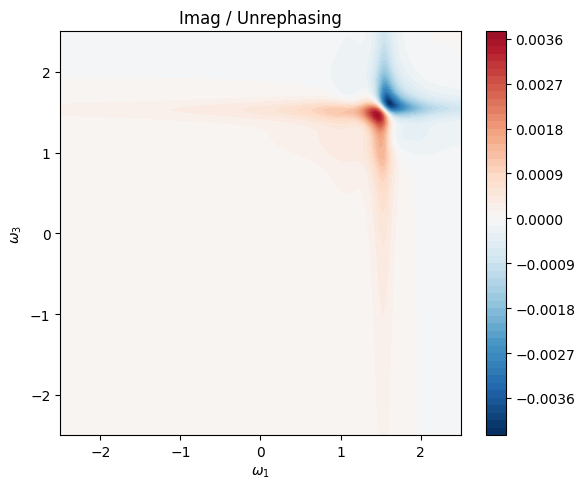

population time: 94 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


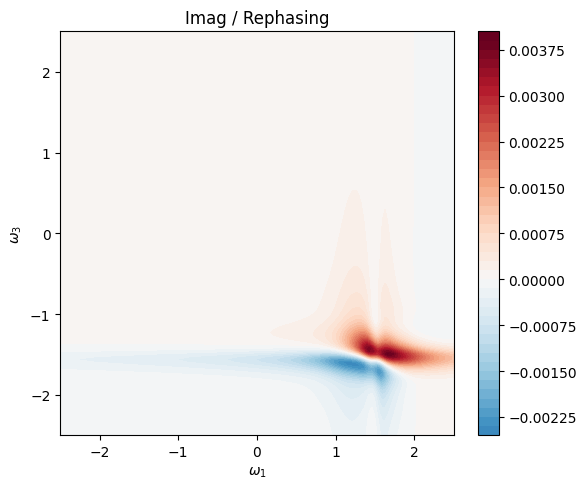

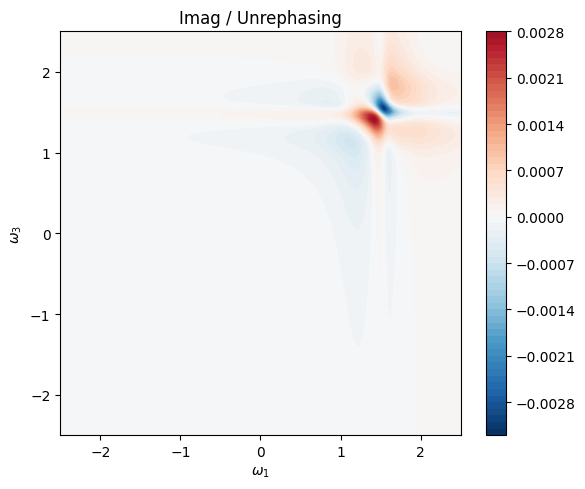

population time: 96 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


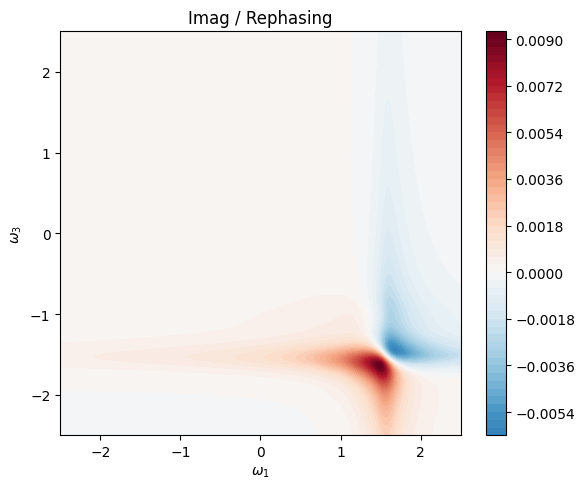

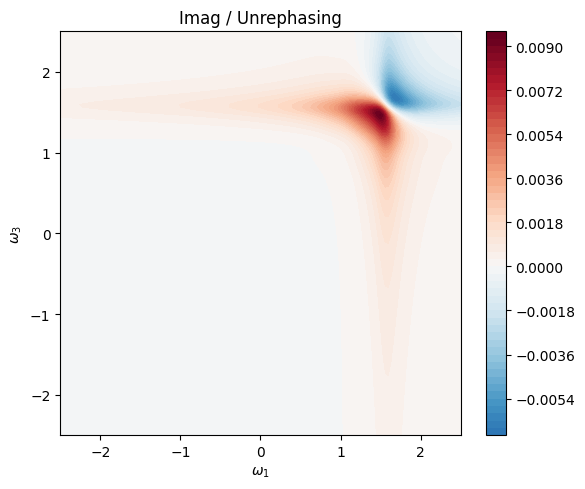

population time: 98 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


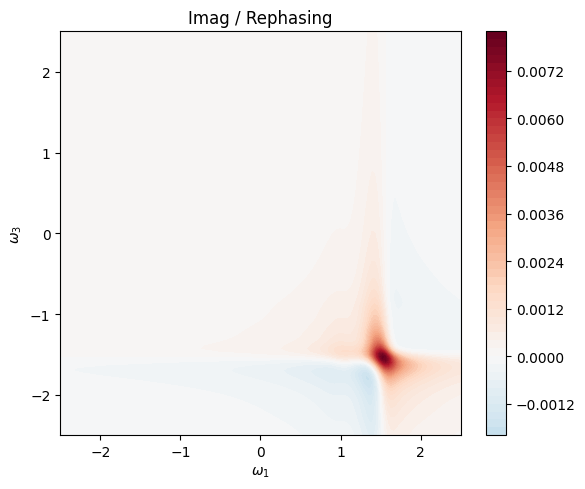

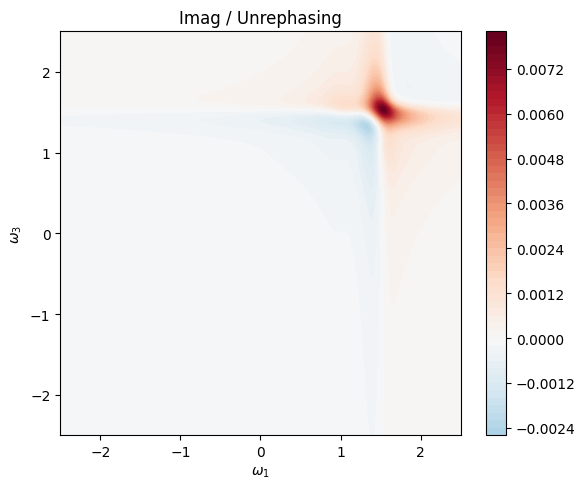

population time: 100 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


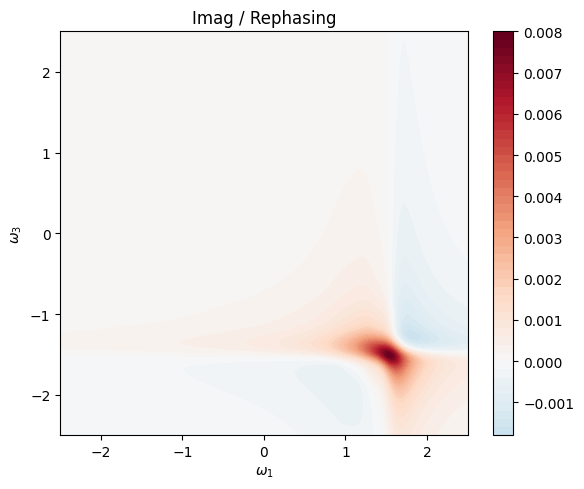

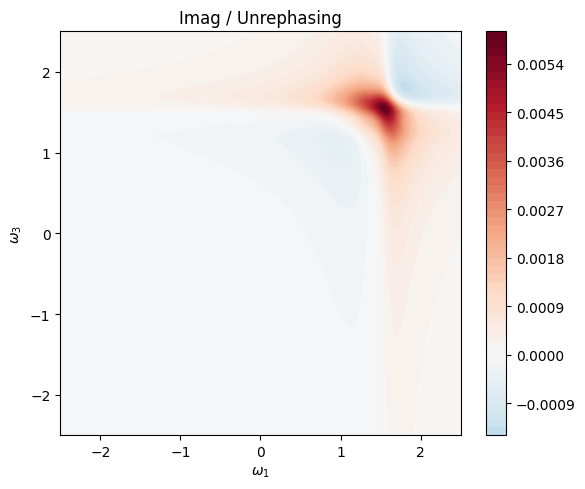

population time: 102 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


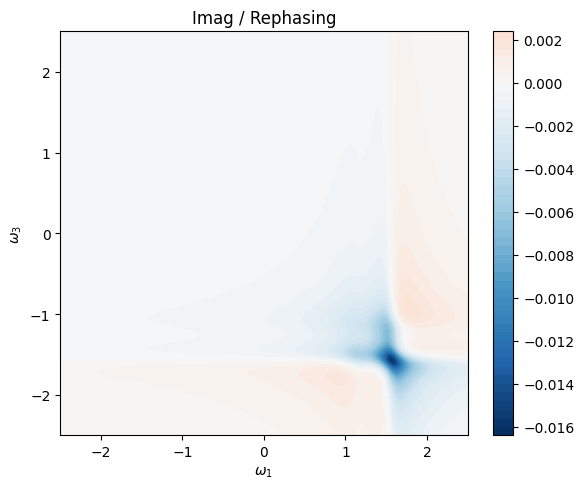

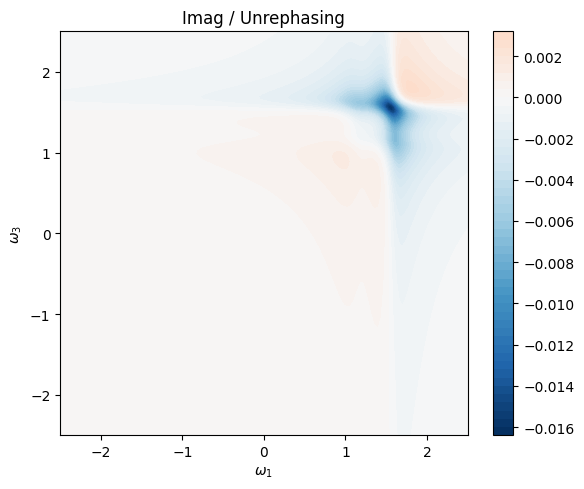

population time: 104 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


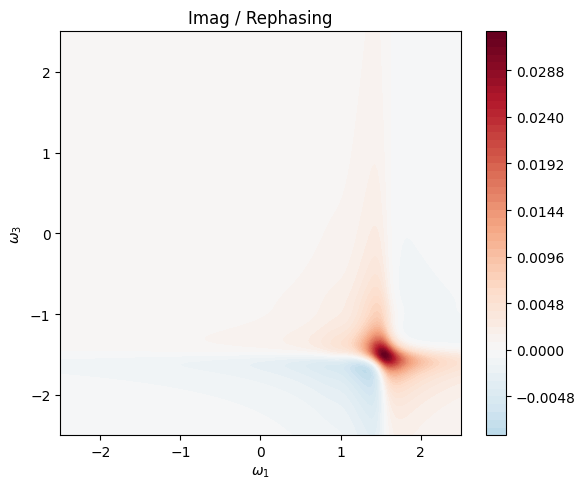

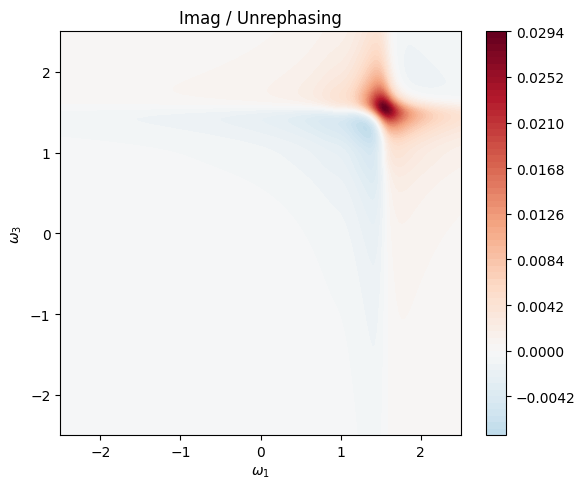

population time: 106 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


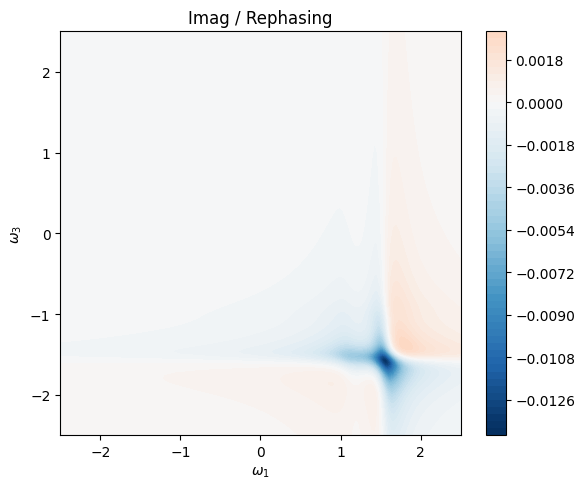

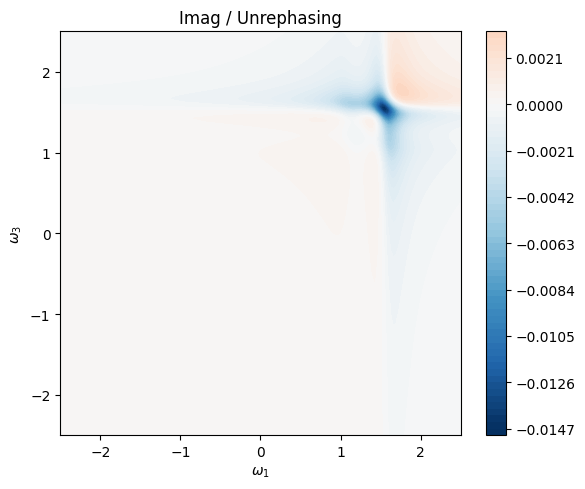

population time: 108 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


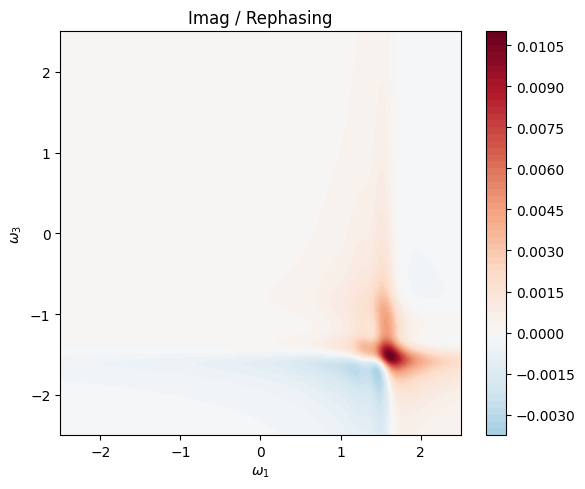

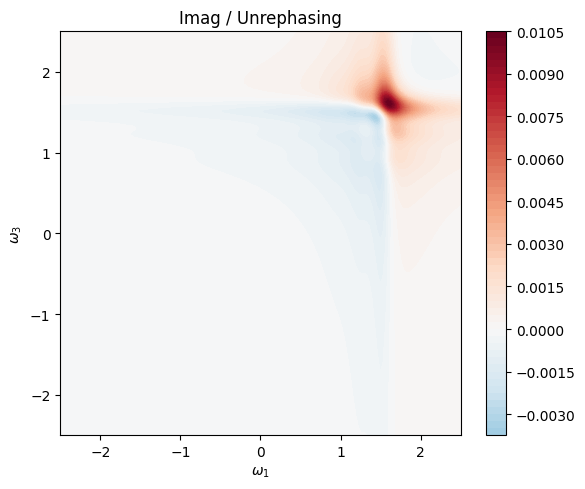

population time: 110 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


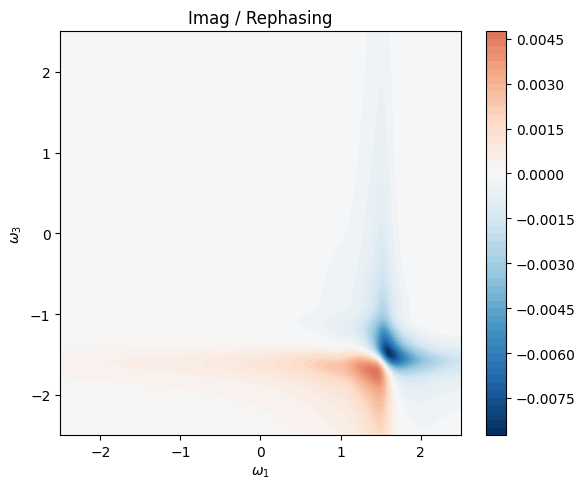

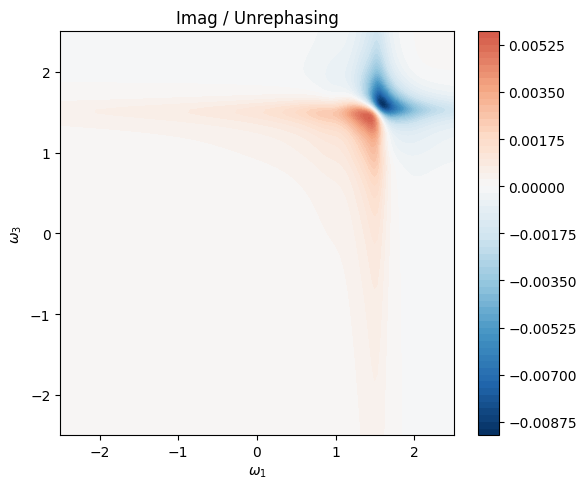

population time: 112 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


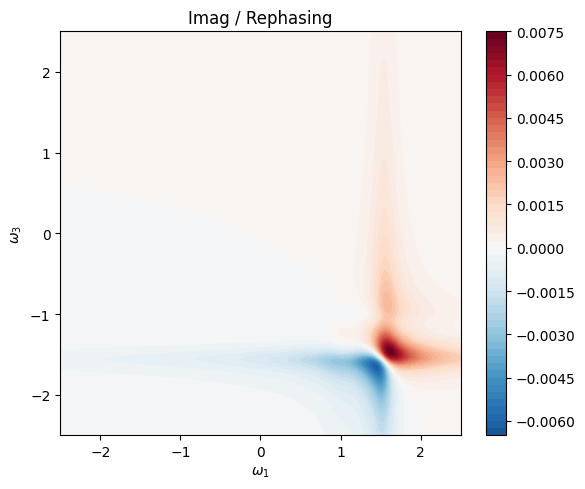

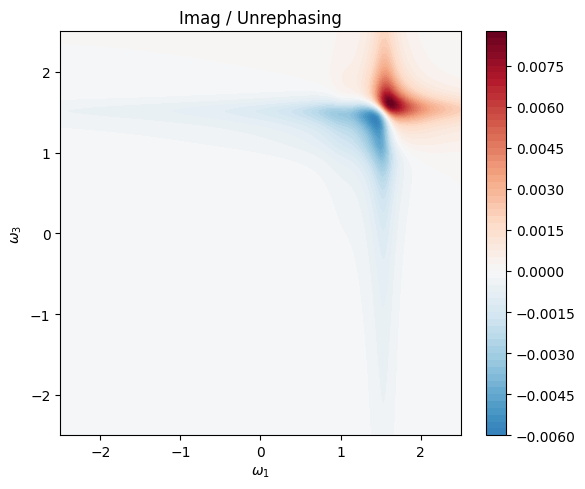

population time: 114 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


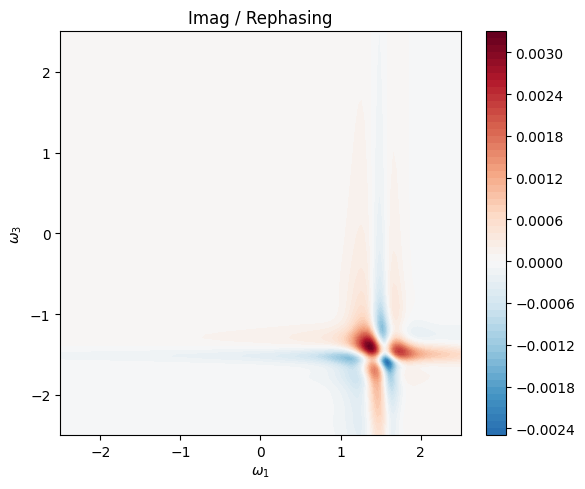

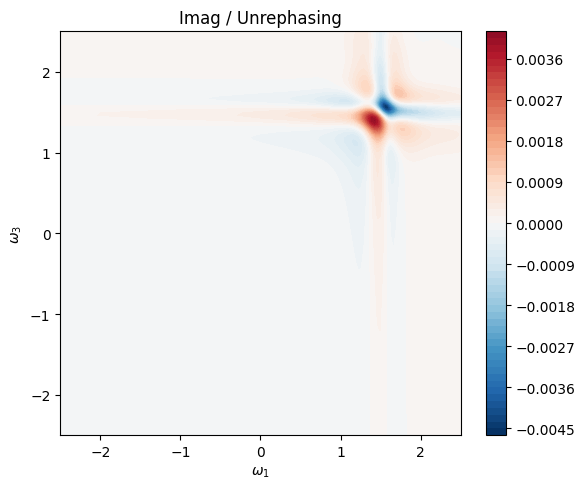

population time: 116 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


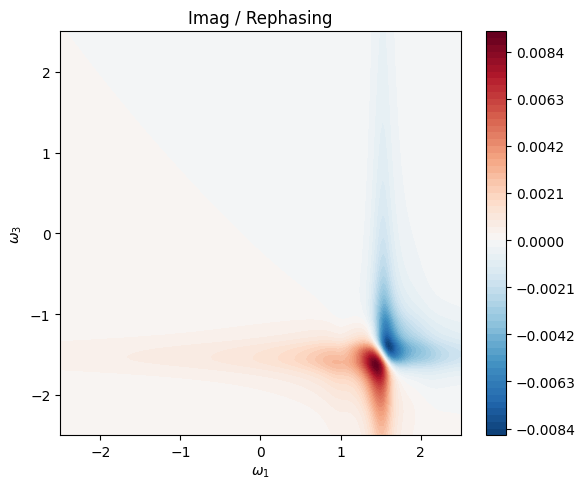

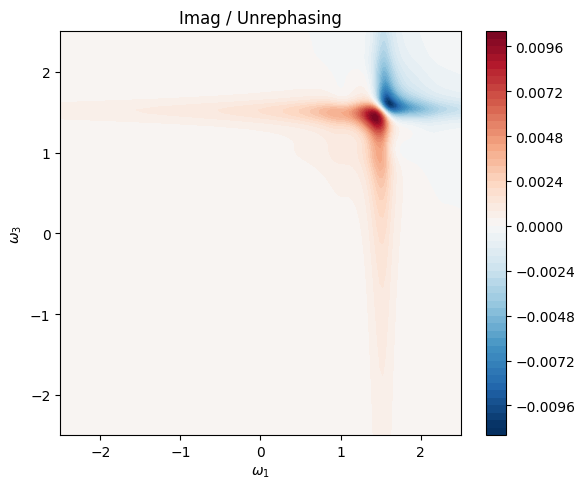

population time: 118 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


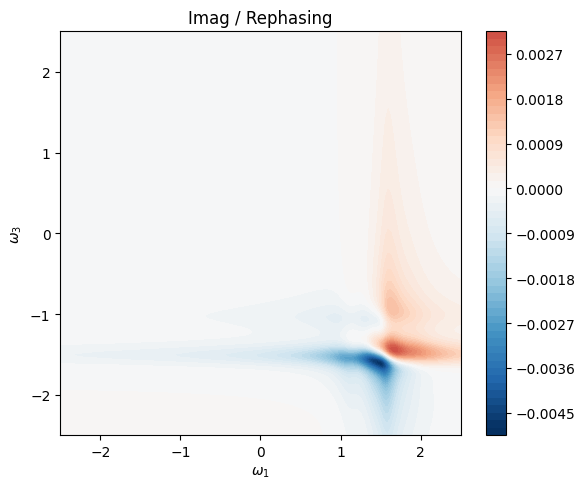

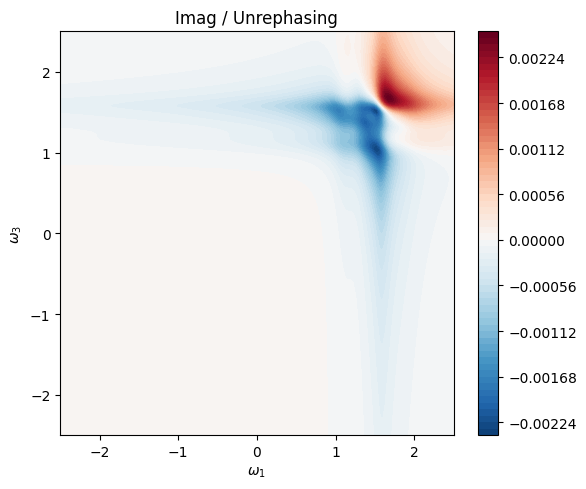

population time: 120 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


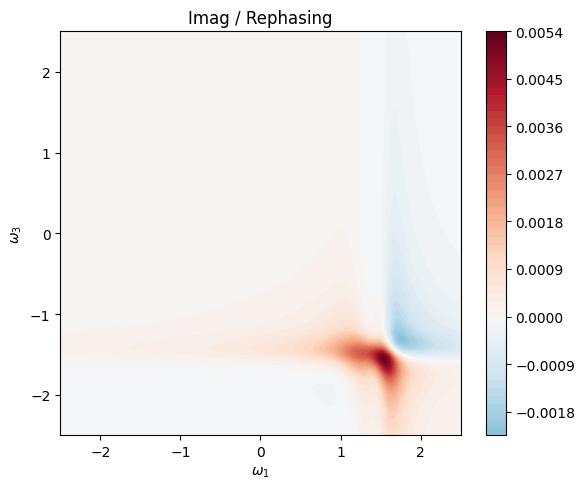

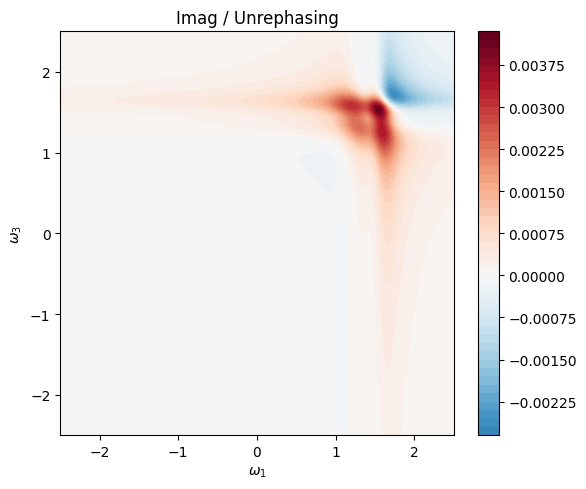

population time: 122 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


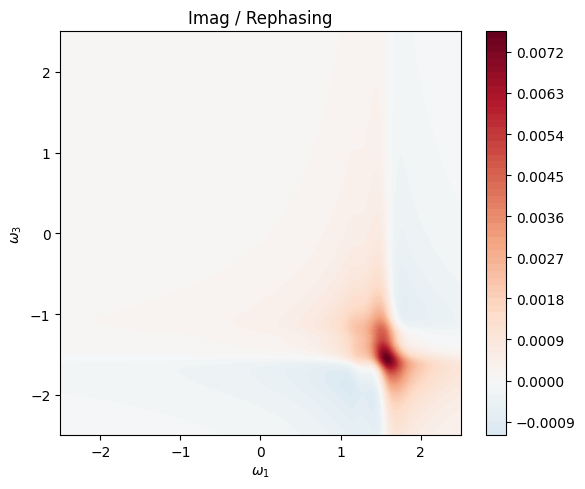

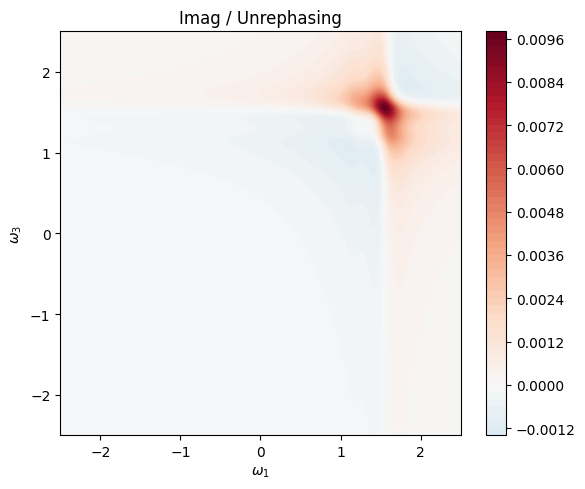

population time: 124 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


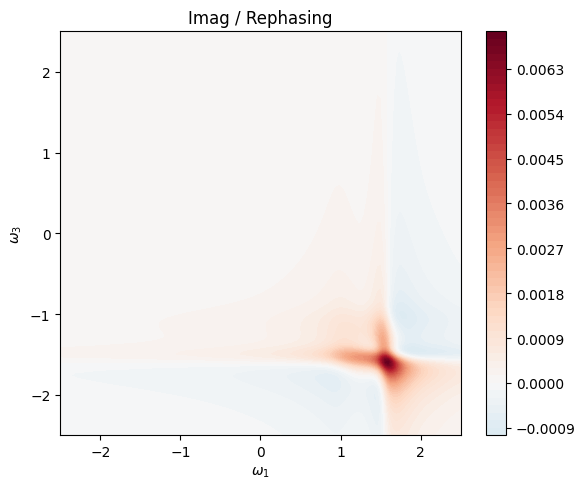

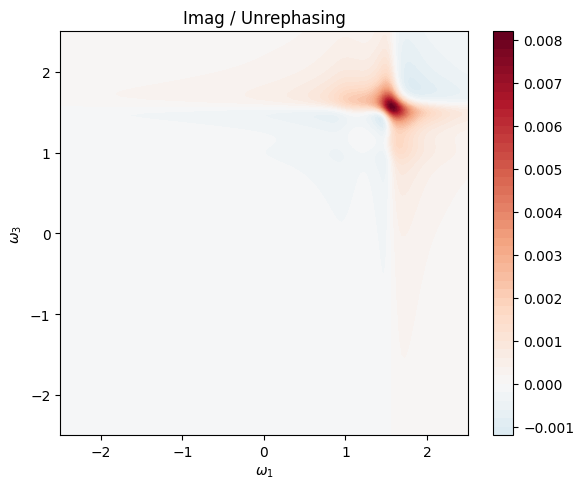

population time: 126 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


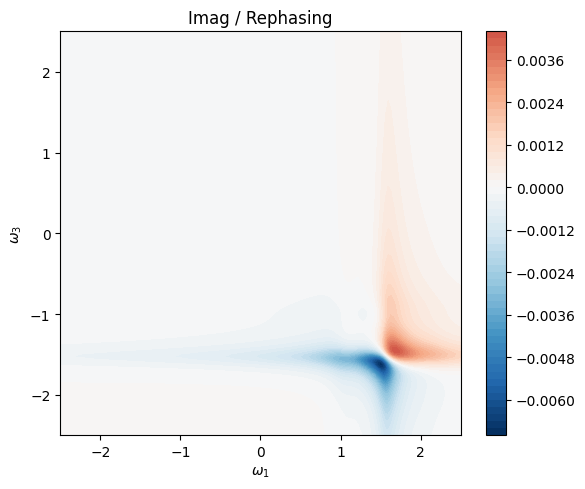

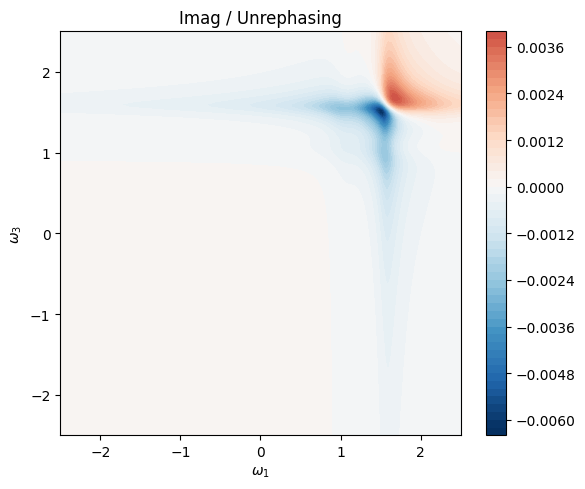

population time: 128 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


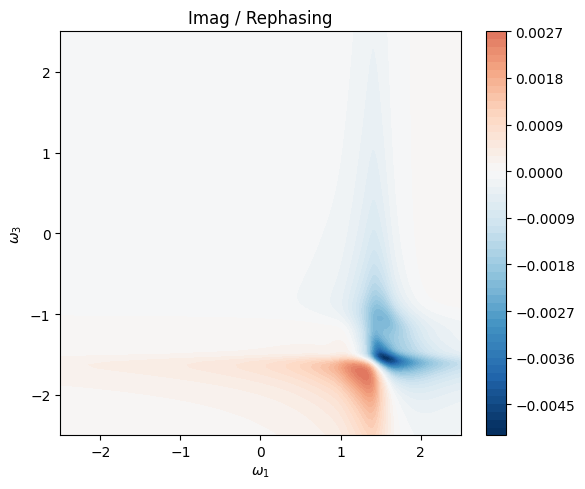

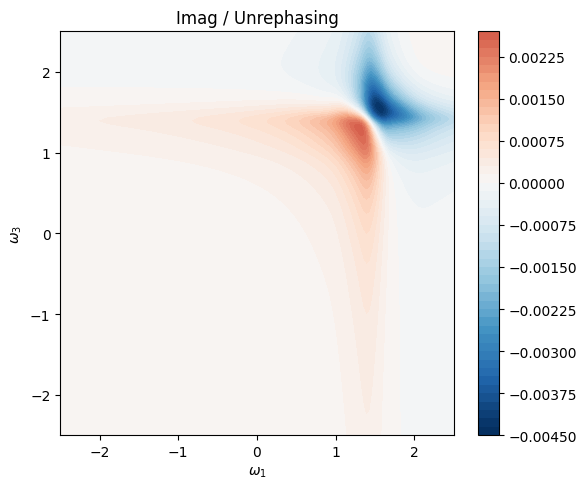

population time: 130 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


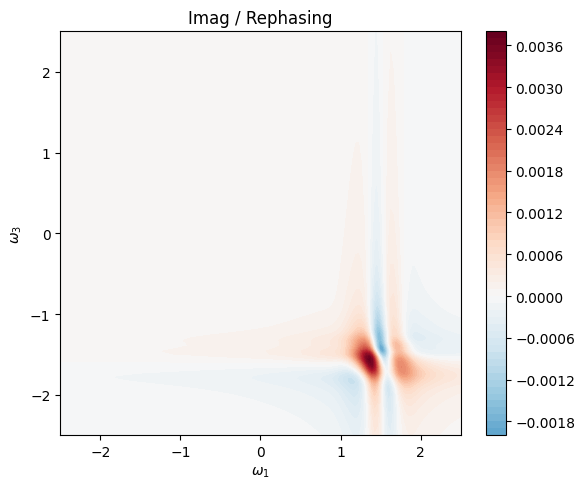

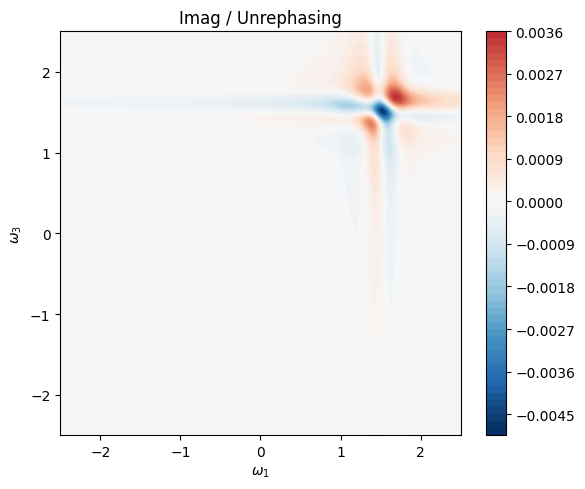

population time: 132 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


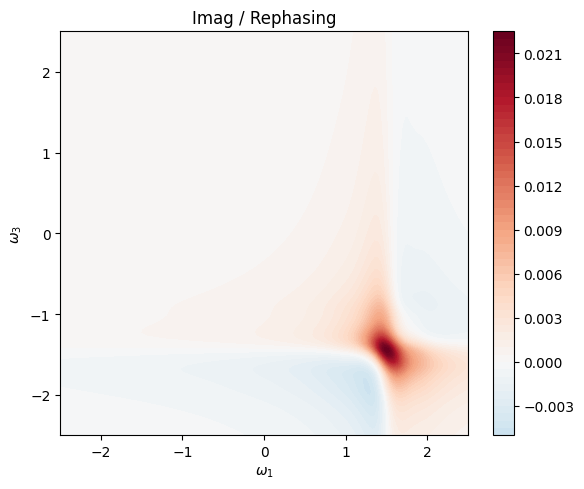

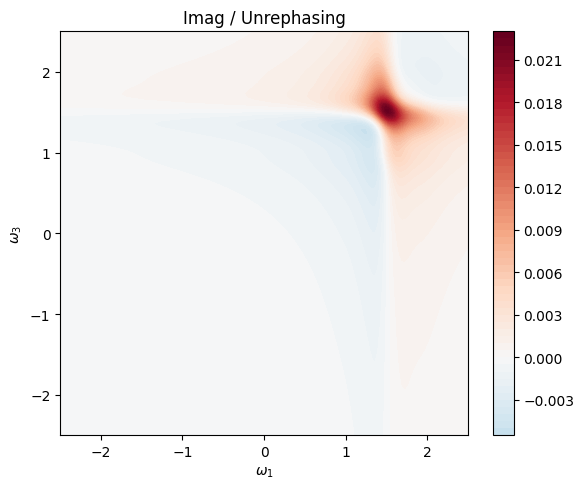

population time: 134 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


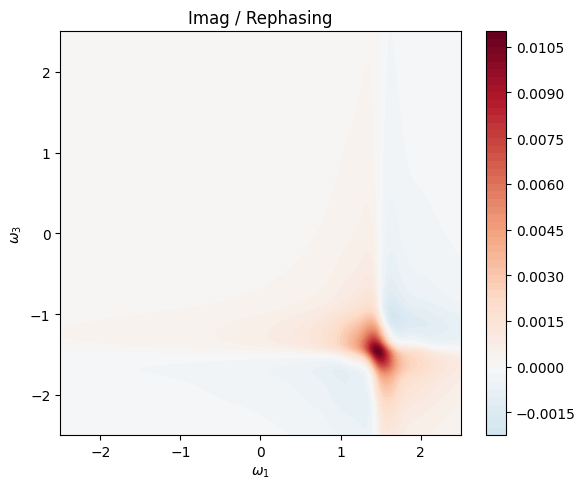

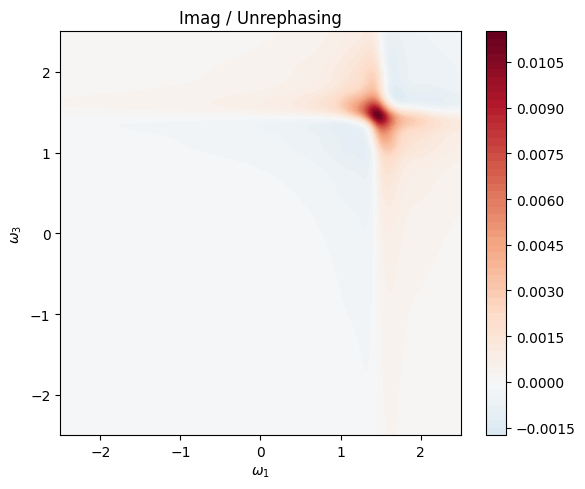

population time: 136 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


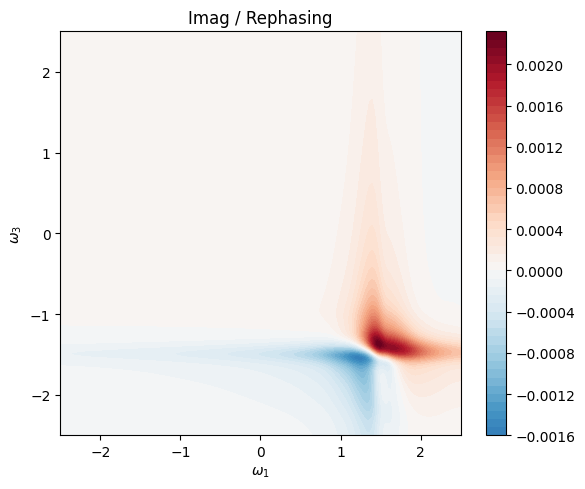

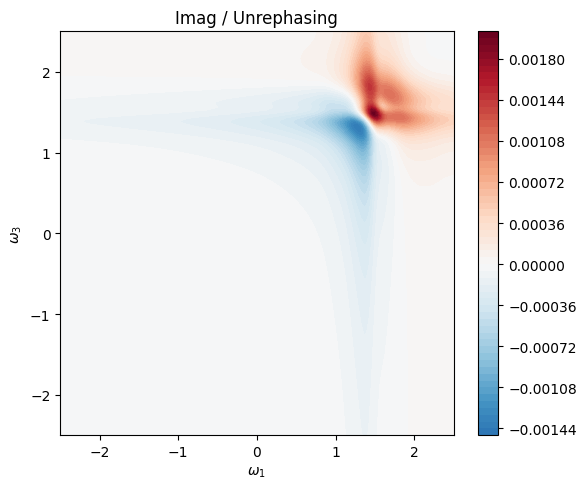

population time: 138 fs
Starting 2D scan on a 150x150 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=6.


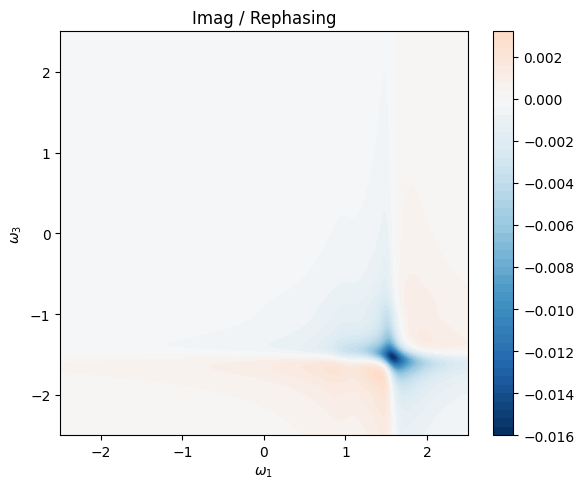

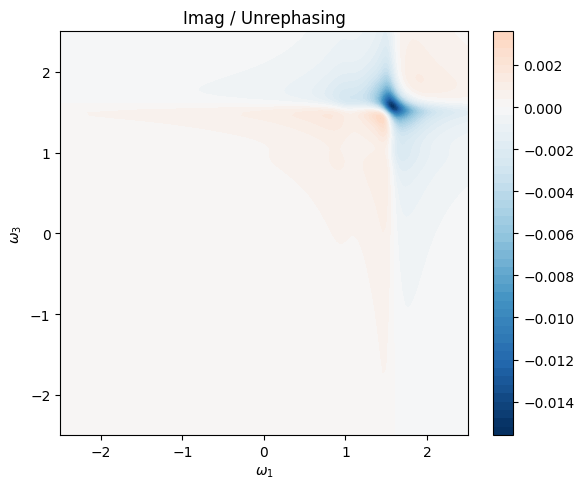

In [16]:
# =============================================================================
# 7. MAIN PROGRAM
# =============================================================================

def main():
    # -------------------------------------------------------------------------
    # Numerical grids
    # -------------------------------------------------------------------------
    k_array = np.linspace(
        SCAN_PARAMS["k_min"],
        SCAN_PARAMS["k_max"],
        SCAN_PARAMS["total_kpoints"],
    )
    w_list = np.linspace(
        SCAN_PARAMS["omega_min"],
        SCAN_PARAMS["omega_max"],
        SCAN_PARAMS["omega_points"],
    )
    tau2 = SCAN_PARAMS["tau2"]

    # -------------------------------------------------------------------------
    # Model construction
    # -------------------------------------------------------------------------
    H_raw, J_raw, mu_opt = build_soc_hamiltonian(k_array, ALL_PARAMS)

    interaction_mode = EXAMPLE_OPTIONS["interaction_mode"].lower()
    if interaction_mode == "dipole":
        interaction_operator = mu_opt
        interaction_type = "dipole"
    elif interaction_mode == "current":
        interaction_operator = J_raw
        interaction_type = "current"
    else:
        raise ValueError(
            "interaction_mode must be 'dipole' or 'current'."
        )

    # -------------------------------------------------------------------------
    # Solver creation and rho(0) selection
    # -------------------------------------------------------------------------
    system = LiouvilleSpectroscopySolver(SOLVER_PARAMS)

    if EXAMPLE_OPTIONS["use_custom_density_matrix"]:
        rho0_site = build_custom_initial_density_matrix(ALL_PARAMS)

        # rho0_site is expressed in the same site/product basis as H_raw.
        system.feed_model(
            H_raw,
            interaction_operator,
            interaction_type=interaction_type,
            initial_density_matrix=rho0_site,
            density_matrix_basis="site",
        )
    else:
        # In the absence of an explicit rho, V6 uses the thermal state built
        # using SOLVER_PARAMS["T"] and SOLVER_PARAMS["mu"].
        system.feed_model(
            H_raw,
            interaction_operator,
            interaction_type=interaction_type,
        )

    # It is also possible to change rho after feed_model:
    #
    # system.set_initial_density_matrix(rho0_site, basis="site")
    #
    # or to restore the thermal state:
    #
    # system.clear_initial_density_matrix()
    #
    # Inspection in the desired basis:
    #
    # rho_eigen = system.get_initial_density_matrix(basis="eigen")
    # rho_site = system.get_initial_density_matrix(basis="site")

    # -------------------------------------------------------------------------
    # Dissipation
    # -------------------------------------------------------------------------
    collapse_operators = build_minimal_lindblad_operators(ALL_PARAMS)

    # The operators were constructed in the site/product basis.
    # The solver transforms them into the eigenbasis of H(k).
    system.set_dissipation(collapse_operators, basis="site")

    # -------------------------------------------------------------------------
    # Pathways
    # -------------------------------------------------------------------------
    if EXAMPLE_OPTIONS["generate_pathways_with_ufss"]:
        # UFSS generates the two standard phase-matching conditions:
        #
        # rephasing   : (-k1, +k2, +k3)
        # unrephasing : (+k1, -k2, +k3)
        #
        # The fourth time represents the detection/local oscillator and
        # does not add an interaction to the third-order pathway.
        system.configure_standard_2d_pathways_with_ufss(
            arrival_times=[0.0, 100.0, 200.0, 300.0],
        )
    else:
        # The six standard pathways integrated into V6 remain active.
        system.reset_pathways()

    # Convenient summary for notebook/console. Each entry contains:
    # name, component, interactions, pulse_indices, amplitude, bra_sign,
    # coefficient.
    pathway_definitions = system.pathway_summary()
    for pathway in pathway_definitions:
        print(pathway)

    # Example of using a list generated elsewhere by UFSS:
    #
    # ufss_diagrams = diagram_generator.get_diagrams(arrival_times)
    # system.set_pathways_from_ufss(
    #     ufss_diagrams,
    #     component="rephasing",
    # )

    # -------------------------------------------------------------------------
    # Total spectra
    # -------------------------------------------------------------------------
    '''
    for i in range(1,20,1):
        print("population time:", i*10, "fs")
        spectra = system.generate_2D_spectra(
            w_list,
            tau2=10*i,
            k_array=k_array,
            # These arguments temporarily override the dictionary values
            # for this specific call only.
            n_jobs=SOLVER_PARAMS["n_jobs"],
            parallel_backend=SOLVER_PARAMS["parallel_backend"],
            block_size=SOLVER_PARAMS["parallel_block_size"],
            blas_threads=SOLVER_PARAMS["blas_threads"],
            spectrum_components=SOLVER_PARAMS["spectrum_components"],
        )

        plotter = SpectroscopyPlotter(w_list)
        plotter.plot_nonrephasing(
            spectra,
            component="imag",
            show=True,
        )
        '''


    # With spectrum_components="both", the dictionary contains:
    '''
    rephasing_spectrum = spectra["rephasing"]
    unrephasing_spectrum = spectra["unrephasing"]
    absorptive_spectrum = spectra["absorptive"]

    # Variables are named here to demonstrate how to access them. They can
    # then be saved, analyzed, or compared.
    _ = (
        rephasing_spectrum,
        unrephasing_spectrum,
        absorptive_spectrum,
    )
    

    # -------------------------------------------------------------------------
    # Individual pathways
    # -------------------------------------------------------------------------
    pathway_spectra = None
    if EXAMPLE_OPTIONS["calculate_individual_pathways"]:
        pathway_spectra = system.generate_2D_pathways(
            w_list,
            tau2=tau2,
            k_array=k_array,
            # To limit the calculation to specific pathways:
            # pathways=["R1", "R2"],
        )

        # Direct access to an individual matrix:
        R1_spectrum = pathway_spectra["R1"]
        _ = R1_spectrum

    # -------------------------------------------------------------------------
    # Plots
    # -------------------------------------------------------------------------
    plotter = SpectroscopyPlotter(w_list)
    show = EXAMPLE_OPTIONS["show_plots"]

    # Single panel, selection of the component:
    plotter.plot_rephasing(
        spectra,
        component="real",
        show=show,
    )
    plotter.plot_unrephasing(
        spectra,
        component="imag",
        show=show,
    )
    plotter.plot_absorptive(
        spectra,
        component="abs",
        show=show,
    )

    # Alias available if the terminology "nonrephasing" is preferred:
    #
    # plotter.plot_nonrephasing(spectra, component="real")

    if pathway_spectra is not None:
        # Plot a single pathway.
        plotter.plot_pathway(
            pathway_spectra,
            "R1",
            component="real",
            show=show,
        )

        # Plot multiple pathways in a grid layout.
        plotter.plot_pathways(
            pathway_spectra,
            pathways=["R1", "R2", "R3", "R4", "R5", "R6"],
            component="abs",
            ncols=3,
            show=show,
        )

    # Legacy V5 figure style, still available:
    #
    # plotter.plot_spectrum(
    #     spectra["rephasing"],
    #     spectra["unrephasing"],
    # )
    '''

    for i in range(1,40,1):
        tau2= i*2 +60
        print("population time:", tau2, "fs")
        spectra = system.generate_2D_spectra(
            w_list,
            tau2=tau2,
            k_array=k_array,
            # These arguments temporarily override the dictionary values
            # for this specific call only.
            n_jobs=SOLVER_PARAMS["n_jobs"],
            parallel_backend=SOLVER_PARAMS["parallel_backend"],
            block_size=SOLVER_PARAMS["parallel_block_size"],
            blas_threads=SOLVER_PARAMS["blas_threads"],
            spectrum_components=SOLVER_PARAMS["spectrum_components"],
        )

        plotter = SpectroscopyPlotter(w_list)

        plotter.plot_rephasing(
            spectra,
            component="imag",
            show=True,
        )

        plotter.plot_nonrephasing(
            spectra,
            component="imag",
            show=True,
        )










if __name__ == "__main__":
    main()
